# Coolant flow distribution across parallel cooling plates

A pump delivers total flow, but the packs or plates connected in parallel do not share it equally.
This notebook builds a small hydraulic network, finds where the pump operates, and shows how the header layout
changes the flow each branch gets and the temperature spread that follows.

All resistances and heat loads are illustrative.

## 1. Pump curve and system curve

Pump: $\Delta P = P_0 - a\,Q^2$. Circuit: $\Delta P = K\,Q^2$. The pump runs where they cross.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

P0, a  = 100e3, 3.6e11        # pump shut-off pressure (Pa) and curve coefficient
Kc     = 1.35e11              # common line (radiator, pipes) coefficient
K0     = 3.6e12               # one cooling-plate branch, 25 kPa at 5 L/min
N      = 4                    # branches in parallel
Kh     = 1.4e10               # one header segment
cp, rho = 3300.0, 1070.0
q_branch = 900.0              # W per branch
lpm = lambda Q: Q*1000*60     # m3/s -> L/min

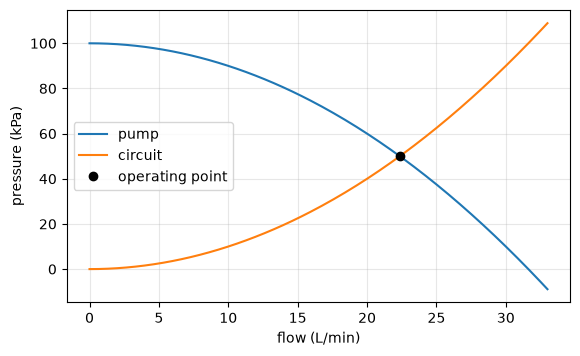

Operating point: 22.4 L/min total, 5.6 L/min per branch, 50 kPa


In [2]:
Q = np.linspace(0, 5.5e-4, 200)
K_sys = Kc + K0/N**2          # N identical branches in parallel, no header loss
Q_op = np.sqrt(P0/(a + K_sys))
plt.figure(figsize=(6.5, 3.8))
plt.plot(lpm(Q), (P0 - a*Q**2)/1e3, label='pump')
plt.plot(lpm(Q), K_sys*Q**2/1e3, label='circuit')
plt.plot(lpm(Q_op), K_sys*Q_op**2/1e3, 'ko', label='operating point')
plt.xlabel('flow (L/min)'); plt.ylabel('pressure (kPa)'); plt.legend(); plt.grid(alpha=.3); plt.show()
print(f'Operating point: {lpm(Q_op):.1f} L/min total, {lpm(Q_op)/N:.1f} L/min per branch, {K_sys*Q_op**2/1e3:.0f} kPa')

**Observation.** The flow you get is where the curves meet, not the flow you would like.
Anything that changes the circuit resistance moves this point.

## 2. Branch flows with a header

Each branch sees the pressure difference between its two header connections, so header losses reduce the pressure available to far branches.
For branch $j$, with flow $Q_j$ and total $Q=\sum Q_j$:

$$K_j Q_j^2 = \Delta P_{avail} - \Delta P_{supply,j} - \Delta P_{return,j}, \qquad \Delta P_{avail}=P_0-(a+K_c)Q^2$$

**U-type:** supply and return both run in the same direction, so the last branch pays for both headers.
**Z-type:** return flows the opposite way, so every branch sees about the same total header loss.

In [3]:
def branch_flows(layout, K):
    K = np.array(K, float)
    def eqs(x):
        Qj = x**2
        Qt = Qj.sum()
        dP = P0 - (a + Kc)*Qt**2
        tail = np.array([Qj[m:].sum() for m in range(N)])     # flow in supply segment m+1
        head = np.array([Qj[:m+1].sum() for m in range(N)])   # flow in return segment (Z-type)
        res = []
        for j in range(N):
            sup = Kh*np.sum(tail[:j+1]**2)
            ret = Kh*np.sum(tail[:j+1]**2) if layout == 'U' else Kh*np.sum(head[j:N-1]**2)
            res.append(K[j]*Qj[j]**2 - (dP - sup - ret))
        return res
    x = fsolve(eqs, np.full(N, np.sqrt(Q_op/N)))
    return x**2

K_equal = np.full(N, K0)
Q_U = branch_flows('U', K_equal)
Q_Z = branch_flows('Z', K_equal)
print('U-type  L/min per branch:', np.round(lpm(Q_U), 2), f' total {lpm(Q_U.sum()):.1f}')
print('Z-type  L/min per branch:', np.round(lpm(Q_Z), 2), f' total {lpm(Q_Z.sum()):.1f}')

U-type  L/min per branch: [5.61 5.43 5.35 5.33]  total 21.7
Z-type  L/min per branch: [5.52 5.44 5.44 5.52]  total 21.9


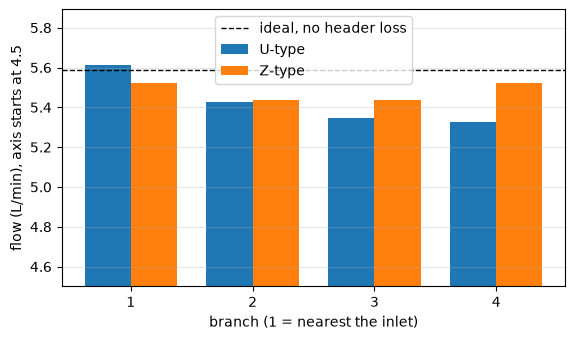

In [4]:
x = np.arange(1, N+1); w = 0.38
plt.figure(figsize=(6.5, 3.6))
plt.bar(x-w/2, lpm(Q_U), w, label='U-type'); plt.bar(x+w/2, lpm(Q_Z), w, label='Z-type')
plt.axhline(lpm(Q_op)/N, color='k', ls='--', lw=1, label='ideal, no header loss')
plt.xticks(x); plt.xlabel('branch (1 = nearest the inlet)'); plt.ylabel('flow (L/min), axis starts at 4.5')
plt.ylim(4.5, None); plt.legend(); plt.grid(alpha=.3, axis='y'); plt.show()

In [5]:
spread = lambda Q: (Q.max()-Q.min())/Q.mean()
print(f'Flow spread (max-min)/mean:  U-type {spread(Q_U):.1%},  Z-type {spread(Q_Z):.1%}')

Flow spread (max-min)/mean:  U-type 5.3%,  Z-type 1.5%


**Observation.** Identical branches do not get identical flow. The layout of the headers alone creates a spread,
and it is larger for the U-type. Manufacturing variation in the branches adds on top of this.

## 3. What the flow spread does to temperature

Coolant outlet rise: $\Delta T_j = \dfrac{q}{\rho Q_j c_p}$.
Plate wall temperature above the inlet, with a convection conductance that scales as $Q^{0.8}$:

$$T_{wall,j}-T_{in} = \frac{\Delta T_j}{2} + \frac{q}{hA_0\,(Q_j/Q_0)^{0.8}}$$

In [6]:
hA0 = 150.0          # W/K per plate at the ideal flow (illustrative)
Q0 = Q_op/N
def temps(Qj):
    dT = q_branch/(rho*Qj*cp)
    wall = dT/2 + q_branch/(hA0*(Qj/Q0)**0.8)
    return dT, wall

for name, Qj in (('U-type', Q_U), ('Z-type', Q_Z)):
    dT, wall = temps(Qj)
    print(f'{name}: outlet rise {np.round(dT,2)} K, wall above inlet {np.round(wall,2)} K, wall spread {wall.max()-wall.min():.2f} K')

U-type: outlet rise [2.73 2.82 2.86 2.87] K, wall above inlet [7.34 7.55 7.65 7.67] K, wall spread 0.33 K
Z-type: outlet rise [2.77 2.81 2.81 2.77] K, wall above inlet [7.45 7.54 7.54 7.45] K, wall spread 0.10 K


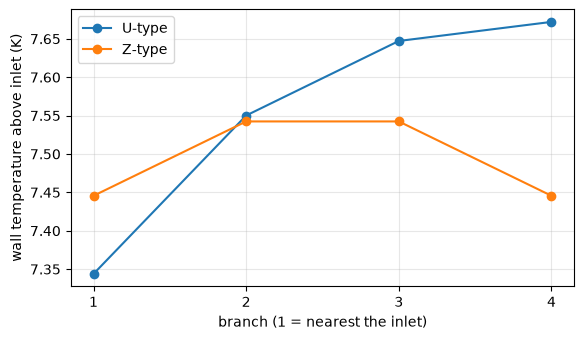

In [7]:
plt.figure(figsize=(6.5, 3.6))
for name, Qj in (('U-type', Q_U), ('Z-type', Q_Z)):
    plt.plot(x, temps(Qj)[1], 'o-', label=name)
plt.xticks(x); plt.xlabel('branch (1 = nearest the inlet)'); plt.ylabel('wall temperature above inlet (K)')
plt.legend(); plt.grid(alpha=.3); plt.show()

**Observation.** A small flow difference gives a small temperature difference here, because the plate is well cooled.
With less coolant flow, a hotter load or a weaker plate the same imbalance matters more, and the hottest branch sets the limit.

## 4. Balancing with orifices

Add a fixed restriction to the branches that get too much flow. Iterate on
$K_j = \Delta P_j / Q_{ref}^2$, never below the plate resistance, until the flows match.

In [8]:
def balance(layout, iters=60):
    K = K_equal.copy()
    for _ in range(iters):
        Qj = branch_flows(layout, K)
        Qt = Qj.sum()
        dP = K*Qj**2
        K = np.maximum(K0, dP/Qj.min()**2)
    return K, branch_flows(layout, K)

K_bal, Q_bal = balance('U')
print('orifice added to each branch (Pa/(m3/s)^2 x 1e9):', np.round((K_bal-K0)/1e9, 1))
print('balanced U-type flow per branch (L/min):', np.round(lpm(Q_bal), 2), f' total {lpm(Q_bal.sum()):.1f}')
print(f'Flow spread after balancing: {spread(Q_bal):.2%};  total flow fell from {lpm(Q_U.sum()):.1f} to {lpm(Q_bal.sum()):.1f} L/min')

orifice added to each branch (Pa/(m3/s)^2 x 1e9): [396.3 144.3  32.3   4.3]
balanced U-type flow per branch (L/min): [5.4 5.4 5.4 5.4]  total 21.6
Flow spread after balancing: 0.00%;  total flow fell from 21.7 to 21.6 L/min


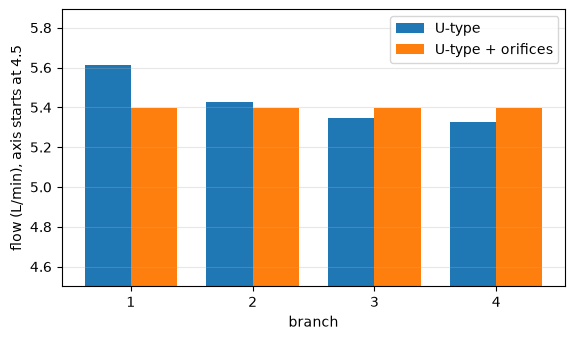

In [9]:
plt.figure(figsize=(6.5, 3.6))
plt.bar(x-w/2, lpm(Q_U), w, label='U-type'); plt.bar(x+w/2, lpm(Q_bal), w, label='U-type + orifices')
plt.xticks(x); plt.ylim(4.5, None); plt.xlabel('branch'); plt.ylabel('flow (L/min), axis starts at 4.5')
plt.legend(); plt.grid(alpha=.3, axis='y'); plt.show()

**Observation.** Orifices even out the flow. They add resistance, so total flow drops a little here (21.7 to 21.6 L/min) because the pump curve is forgiving.
In a circuit with less margin the loss is larger. Fixing the header layout (Z-type) balances the flow without adding any resistance,
so the geometry is worth changing first.

**Limits.** Incompressible, constant properties, quadratic losses, a four-branch toy network, illustrative numbers.
A real design needs measured pressure-drop data for the plates, headers and fittings.